# S11 – Компьютерное зрение (PyTorch): Детекция «из коробки» и IoU sanity-check

В S10 мы закрепили CNN и transfer learning для **классификации**.  
В S11 переходим к задачам, где выход модели уже **не класс**, а **геометрия** (bbox/маски).

В этом ноутбуке:
- запускаем **готовый детектор** из `torchvision` (COCO-pretrained);
- визуализируем предсказанные **bounding boxes**;
- делаем «sanity-check» качества на маленькой выборке: **IoU@0.5 → precision/recall** (это не mAP, но уже честная проверка).

Датасет для демонстрации: **PennFudanPed** (пешеходы).  
Если интернет недоступен – можно положить распакованную папку `PennFudanPed/` в `DATA_DIR` вручную.


In [1]:
# 1) Импорты и общие настройки
import os
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

torch: 2.10.0+cu128
device: cuda


In [2]:
# 2) Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.6          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=False, n_show=4, score_thr=0.6, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [3]:
# 3) Данные: PennFudanPed (download/unzip при необходимости)

PENN_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"

def ensure_pennfudan(root: str) -> str:
    '''
    Гарантируем наличие папки root/PennFudanPed.
    Возвращаем путь к PennFudanPed.
    '''
    penn_root = os.path.join(root, "PennFudanPed")
    if os.path.isdir(penn_root):
        return penn_root

    os.makedirs(root, exist_ok=True)

    # Скачивание через torchvision утилиту (если доступно)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        print("Downloading PennFudanPed to:", root)
        download_and_extract_archive(PENN_URL, download_root=root, filename="PennFudanPed.zip", remove_finished=False)
        if not os.path.isdir(penn_root):
            raise FileNotFoundError("После распаковки не найдено PennFudanPed/. Проверьте содержимое папки data_dir.")
        return penn_root
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {PENN_URL}")
        print(f"2) распакуйте так, чтобы было: {penn_root}/PNGImages и {penn_root}/PedMasks")
        raise

penn_root = ensure_pennfudan(cfg.data_dir)
penn_root

100%|██████████| 53.7M/53.7M [00:01<00:00, 32.2MB/s]


'./data/PennFudanPed'

In [4]:
# 4) Dataset: читаем изображения и маски, извлекаем bbox из масок
# PennFudanPed содержит instance masks (каждый пешеход – отдельный id в маске).

import torch.utils.data

class PennFudanDetDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "PNGImages")
        self.mask_dir = os.path.join(root, "PedMasks")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".png")])
        self.masks = sorted([f for f in os.listdir(self.mask_dir) if f.lower().endswith(".png")])

        if len(self.imgs) == 0 or len(self.imgs) != len(self.masks):
            raise RuntimeError("Похоже, структура PennFudanPed повреждена или не распакована полностью.")

        # преобразуем PIL -> torch.Tensor [0..1]
        try:
            from torchvision.transforms import ToTensor
            self.to_tensor = ToTensor()
        except Exception as e:
            raise RuntimeError("Нужен torchvision для ToTensor().") from e

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        mask_np = np.array(mask)
        obj_ids = np.unique(mask_np)
        obj_ids = obj_ids[1:]  # 0 = background

        masks = mask_np == obj_ids[:, None, None]   # [N, H, W] boolean

        boxes = []
        for m in masks:
            ys, xs = np.where(m)
            xmin, xmax = xs.min(), xs.max()
            ymin, ymax = ys.min(), ys.max()
            boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)  # в датасете только "person"
        image_id = torch.tensor([idx], dtype=torch.int64)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        img_t = self.to_tensor(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = PennFudanDetDataset(penn_root)
len(dataset), dataset[0][0].shape, dataset[0][1].keys()

(170,
 torch.Size([3, 536, 559]),
 dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd']))

In [5]:
# 5) Модель: COCO-pretrained detector из torchvision

def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 166MB/s]


model: fasterrcnn_mobilenet_v3_large_fpn
person_label: 1


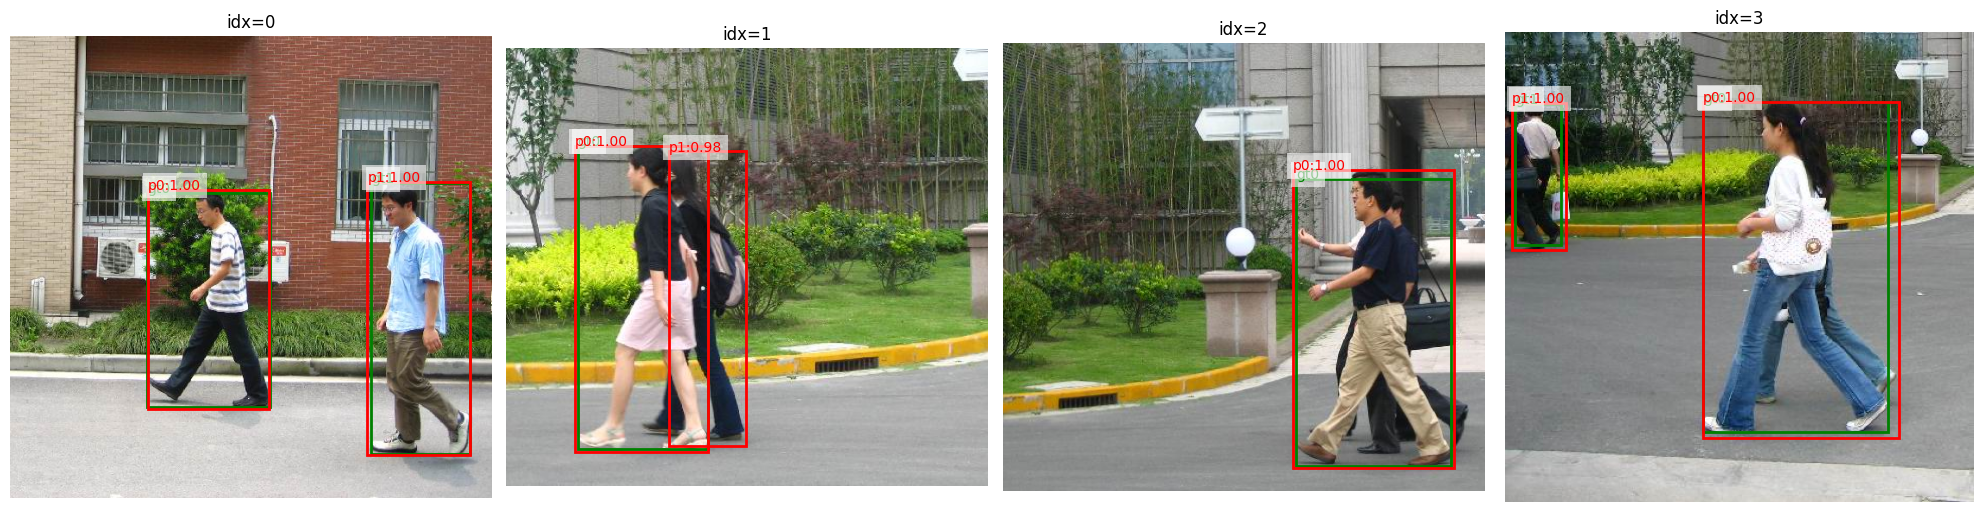

In [6]:
# 6) Инференс и визуализация bbox

def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [7]:
# 7) IoU sanity-check: TP/FP/FN при IoU>=thr (это НЕ mAP, но уже честная проверка)

def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = evaluate_subset(eval_indices)
metrics

{'TP': 418.0,
 'FP': 253.0,
 'FN': 5.0,
 'precision@IoU': 0.6229508196712028,
 'recall@IoU': 0.9881796690283967,
 'F1@IoU': 0.7641681896522682,
 'mean_IoU_matched': 0.9051248351457405}

## Что дальше

1) Это был **sanity-check**. Для метрики уровня статей обычно считают **mAP** (COCO-style) и используют COCO API.  
2) Следующий шаг (уже как самостоятельная работа) – **fine-tune** детектора на PennFudan: там появляются специфичные loss'ы и аккуратная валидация.
